# DocTR extract lines from image

Install packages

In [2]:
!pip install python-doctr[viz] opencv-python numpy

Import detection predictor

List of all models:
https://mindee.github.io/doctr/using_doctr/using_models.html

In [20]:
import cv2 as cv
import json
from doctr.models import detection_predictor

model = detection_predictor('db_resnet50', pretrained=True, assume_straight_pages=False, preserve_aspect_ratio=True)

image = cv.imread(r"test\test-Yves_026_None.png")
out = model([image])

print(out[0])


{'words': array([[[0.88871704, 0.90722656],
        [0.94424804, 0.90722656],
        [0.94424804, 0.91699219],
        [0.88871704, 0.91699219],
        [0.        , 0.60023308]],

       [[0.94851966, 0.90722656],
        [0.96275838, 0.90722656],
        [0.96275838, 0.91503906],
        [0.94851966, 0.91503906],
        [0.        , 0.51525999]],

       [[0.84457701, 0.90625   ],
        [0.88444542, 0.90625   ],
        [0.88444542, 0.91601562],
        [0.84457701, 0.91601562],
        [0.        , 0.60830067]],

       ...,

       [[0.4288064 , 0.0625    ],
        [0.45585997, 0.0625    ],
        [0.45585997, 0.07226562],
        [0.4288064 , 0.07226562],
        [0.        , 0.63086161]],

       [[0.36900378, 0.06152344],
        [0.42311092, 0.06152344],
        [0.42311092, 0.07128906],
        [0.36900378, 0.07128906],
        [0.        , 0.67424097]],

       [[0.13833653, 0.05957031],
        [0.17250945, 0.05957031],
        [0.17250945, 0.07324219],
        [0.1383

### The output of detection_predictor of DocTR is structured as follows:

Structure: A dictionary with a 'words' key containing a NumPy array

Shape: (766, 5, 2) - This means 766 detected text regions, each defined by 5 coordinate pairs

Coordinates: Each text region is represented by 4 corner points plus a confidence score:

The first 4 coordinate pairs [x, y] define the bounding box corners of detected text

The 5th element [0.0, confidence_score] contains the confidence score for that detection

All coordinates are normalized (between 0 and 1) relative to the image dimensions

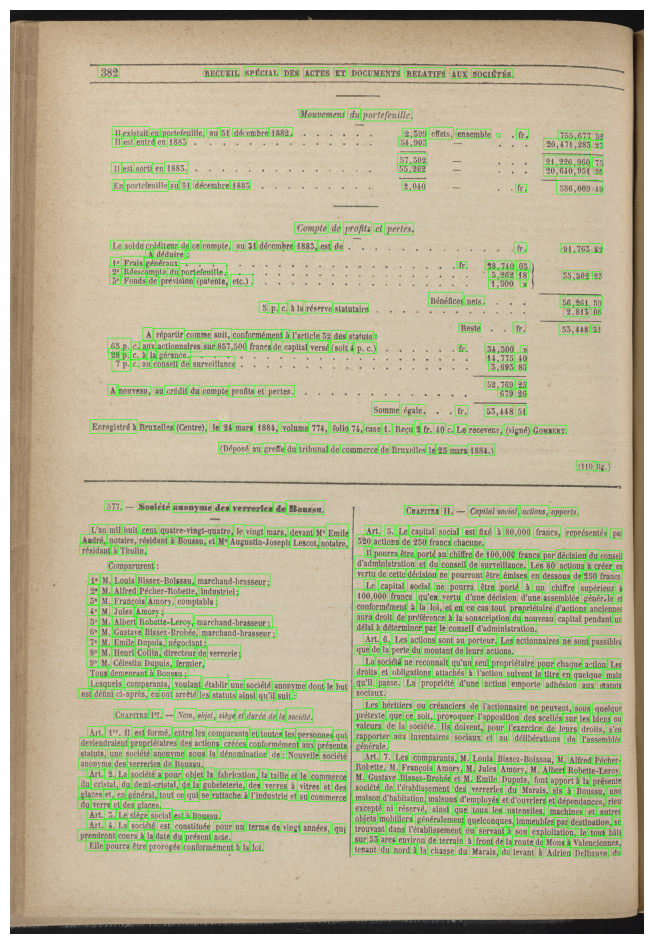

In [ ]:
words_array = out[0]['words']
for i, box in enumerate(words_array):
    
    # Extract these pairs, I think the others can work to
    x1 = box[0][0]
    y1 = box[0][1]
    x2 = box[2][0]
    y2 = box[2][1]

    # Normalization
    h, w = image.shape[:2]
    pt1 = (int(x1 * w), int(y1 * h))
    pt2 = (int(x2 * w), int(y2 * h))
    cv.rectangle(image, pt1, pt2, (0, 255, 0), 2)

# Use matplotlib to display the image in Jupyter Notebook
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
